#**Exploratory Data Analysis of Telecom Customer Churn**

#**Problem Statement**

The telecom industry experiences **high customer churn**, making it crucial to understand why **customers leave**. This **EDA** aims to identify key patterns, trends, and factors influencing **churn** by analyzing **customer demographics**, services, billing details, and account information. The goal is to uncover actionable **insights** that help improve customer **retention** and support future **churn prediction** models.

#**Objectives**

-  Identify the overall churn rate and compare it with active customers.

-  Analyze key features such as demographics, services, billing, and account details that influence customer churn.

-  Uncover important patterns, correlations, and trends using EDA.

-  Provide actionable insights to improve customer retention strategies.



#**Import libraries**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#**Load dataset**

In [ ]:
data=pd.read_csv('telecom_churn_data.csv')
data

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,NaN,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


#**Data Description**

The dataset contains **customer information** from a telecom company, including demographics, service subscriptions, account details, billing information, and a **churn flag** indicating whether a customer has left the service. It helps analyze **customer behavior** and identify key factors contributing to **customer churn**.

**customerID** – Unique identifier assigned to each customer.

**gender** – Customer’s gender (Male/Female).

**SeniorCitizen** – Indicates if the customer is a senior citizen (0 = No, 1 = Yes).

**Partner** – Whether the customer has a partner (Yes/No).

**Dependents** – Whether the customer has dependents (Yes/No).

**tenure** – Number of months the customer has stayed with the company.

**PhoneService** – Indicates if the customer has phone service (Yes/No).

**MultipleLines** – Availability of multiple phone lines.

**InternetService** – Type of internet service (DSL/Fiber optic/No).

**OnlineSecurity** – Online security service status.

**OnlineBackup** – Online backup service status.

**DeviceProtection** – Device protection plan status.

**TechSupport** – Technical support service status.

**StreamingTV** – Access to streaming TV service.

**StreamingMovies** – Access to streaming movie service.

**Contract** – Customer’s contract type (Month-to-month/One year/Two year).

**PaperlessBilling** – Indicates if customer uses paperless billing (Yes/No).

**PaymentMethod** – Customer’s mode of payment.

**MonthlyCharges** – Monthly charges billed to the customer.

**TotalCharges** – Total charges incurred by the customer.

**Churn** – Indicates whether the customer has discontinued the service (Yes/No).

#**Basic Checks**

In [ ]:
#check number of rows and columns
data.shape

(7043, 21)

#There are 7043 number of rows and 21 columns

In [ ]:
#fetch first 5 rows
data.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,NaN,Electronic check,70.70,151.65,Yes


In [ ]:
#Fetch last 5 rows
data.tail()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes
7042,3186-AJIEK,Male,0,No,No,66,Yes,No,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.65,6844.5,No


In [ ]:
#Check mean and standard deviation
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7038 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7041 non-null   object 


In [ ]:
#check data types
data.dtypes

,0
customerID,object
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object


In [ ]:
#Print all columns
data.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [ ]:
#fetch a numerical columns
num_data=data.select_dtypes(include=['int64','float64'])
num_data

,SeniorCitizen,tenure,MonthlyCharges
0,0,1,29.85
1,0,34,56.95
2,0,2,53.85
3,0,45,42.30
4,0,2,70.70
...,...,...,...
7038,0,24,84.80
7039,0,72,103.20
7040,0,11,29.60
7041,1,4,74.40


In [ ]:
#fetrch categorical columns
cat_data=data.select_dtypes(include='object')
cat_data

,customerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,TotalCharges,Churn
0,7590-VHVEG,Female,Yes,No,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,No
1,5575-GNVDE,Male,No,No,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,1889.5,No
2,3668-QPYBK,Male,No,No,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,108.15,Yes
3,7795-CFOCW,Male,No,No,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),1840.75,No
4,9237-HQITU,Female,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,NaN,Electronic check,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,Yes,Yes,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,1990.5,No
7039,2234-XADUH,Female,Yes,Yes,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),7362.9,No
7040,4801-JZAZL,Female,Yes,Yes,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,346.45,No
7041,8361-LTMKD,Male,Yes,No,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,306.6,Yes


In [ ]:
#check unique values
data.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7041.000000
mean,0.162147,32.371149,64.749581
std,0.368612,24.559481,30.085731
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [ ]:
#find unique values
df=cat_data.drop(columns=['customerID','TotalCharges'])
for x in df:
  print(f"{x}--->,{df[x].unique()}")
  print(" ")

gender--->,['Female' 'Male' nan]
 
Partner--->,['Yes' 'No']
 
Dependents--->,['No' 'Yes']
 
PhoneService--->,['No' 'Yes']
 
MultipleLines--->,['No phone service' 'No' 'Yes']
 
InternetService--->,['DSL' 'Fiber optic' 'No']
 
OnlineSecurity--->,['No' 'Yes' 'No internet service']
 
OnlineBackup--->,['Yes' 'No' 'No internet service']
 
DeviceProtection--->,['No' 'Yes' 'No internet service']
 
TechSupport--->,['No' 'Yes' 'No internet service']
 
StreamingTV--->,['No' 'Yes' 'No internet service']
 
StreamingMovies--->,['No' 'Yes' 'No internet service']
 
Contract--->,['Month-to-month' 'One year' 'Two year']
 
PaperlessBilling--->,['Yes' 'No' nan]
 
PaymentMethod--->,['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']
 
Churn--->,['No' 'Yes']
 


In [ ]:
#find value counts
df=cat_data.drop(columns=['customerID','TotalCharges'])
for x in df:
  print(f"{x}-->,{df[x].value_counts}")
  print(" ")

gender-->,<bound method IndexOpsMixin.value_counts of 0       Female
1         Male
2         Male
3         Male
4       Female
         ...  
7038      Male
7039    Female
7040    Female
7041      Male
7042      Male
Name: gender, Length: 7043, dtype: object>
 
Partner-->,<bound method IndexOpsMixin.value_counts of 0       Yes
1        No
2        No
3        No
4        No
       ... 
7038    Yes
7039    Yes
7040    Yes
7041    Yes
7042     No
Name: Partner, Length: 7043, dtype: object>
 
Dependents-->,<bound method IndexOpsMixin.value_counts of 0        No
1        No
2        No
3        No
4        No
       ... 
7038    Yes
7039    Yes
7040    Yes
7041     No
7042     No
Name: Dependents, Length: 7043, dtype: object>
 
PhoneService-->,<bound method IndexOpsMixin.value_counts of 0        No
1       Yes
2       Yes
3        No
4       Yes
       ... 
7038    Yes
7039    Yes
7040     No
7041    Yes
7042    Yes
Name: PhoneService, Length: 7043, dtype: object>
 
MultipleLines-->,<bou

#**Data Preprocessing**

#**check duplicate values**

In [ ]:
data.duplicated().sum()

np.int64(0)

**There is no duplicate values are available**

#**check missing values**

In [ ]:
data.isnull().sum()

,0
customerID,0
gender,5
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


**Missing values are seen in TotalCharges, MonthlyCharges,Paperlessbilling,Gender**

#**Handle missing values**

**Gender**

In [ ]:
#check data type
data.loc[:,'gender'].dtypes

dtype('O')

since data type of gender is object we have to replace with mode value






In [ ]:
#find mode
data.loc[:,'gender'].mode()[0]

'Male'

In [ ]:
#replace missing value with male in gender columns
data.loc[:,'gender']=data.loc[:,'gender'].fillna(data.loc[:,'gender'].mode()[0])

In [ ]:
data.loc[:,'gender'].isnull().sum()

np.int64(0)

**Paperlessbilling**

In [ ]:
#check data type of PaperlessBilling
data.loc[:,'PaperlessBilling'].dtypes

dtype('O')

since data type of paperlessbilling is object we have to replace with mode value

In [ ]:
#find mode of PaperlessBilling
data.loc[:,'PaperlessBilling'].mode()[0]

'Yes'

In [ ]:
#replace missing value with yes
data.loc[:,'PaperlessBilling']=data.loc[:,'PaperlessBilling'].fillna(data.loc[:,'PaperlessBilling'].mode()[0])

In [ ]:
data.loc[:,'PaperlessBilling'].isnull().sum()

np.int64(2)

**Monthly Charges**

In [ ]:
#check data type of Monthly Charges
data.loc[:,'MonthlyCharges'].dtypes

dtype('float64')

np.float64(-0.22028439456532767)

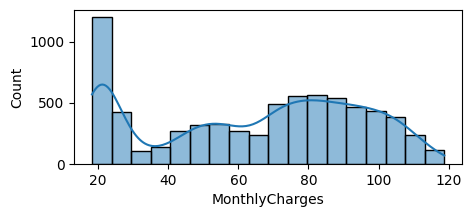

In [ ]:
#since datatype is float we have to check distribution
plt.figure(figsize=(5,2))
sns.histplot(data,x='MonthlyCharges',kde=True)
data.loc[:,'MonthlyCharges'].skew()

**Since distribution of Monthly Charges is normal so we have to replace missing value with mean**

In [ ]:
#Find mean value
data.loc[:,'MonthlyCharges'].mean()

np.float64(64.74958102542253)

In [ ]:
data.loc[:,'MonthlyCharges']=data.loc[:,'MonthlyCharges'].fillna(data.loc[:,'MonthlyCharges'].mean())

In [ ]:
data.loc[:,'MonthlyCharges'].isnull().sum()

np.int64(0)

**TotalCharges**

In [ ]:
#check data type
data.loc[:,'TotalCharges'].dtypes

dtype('O')

**Since the data type of Total Charges is float64 but it shows a 'object' so we have to convert the object into float64**

In [ ]:
#convert obgect int float
data.loc[:,'Total_Charges']=pd.to_numeric(data.loc[:,'TotalCharges'],errors='coerce')

In [ ]:
#check data type
data.loc[:,'Total_Charges'].dtypes

dtype('float64')

np.float64(0.9616058347613503)

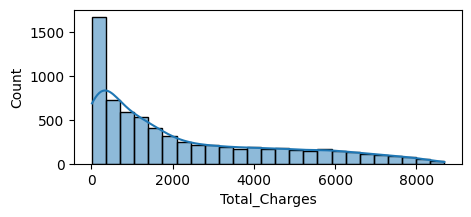

In [ ]:
#check distribution
plt.figure(figsize=(5,2))
sns.histplot(data,x='Total_Charges',kde=True)
data.loc[:,'Total_Charges'].skew()


**Dta distribution is skewed spo we have to replace with median**

In [ ]:
#find meadin value
data.loc[:,'Total_Charges'].median()

1397.3

In [ ]:
#replace missing value with median
data.loc[:,'Total_Charges']=data.loc[:,'Total_Charges'].fillna(data.loc[:,'Total_Charges'].median())

In [ ]:
data.loc[:,'Total_Charges'].isnull().sum()

np.int64(0)

#**Expolore Data using visualization**

**what is the count of customer churn(Yes/No)**

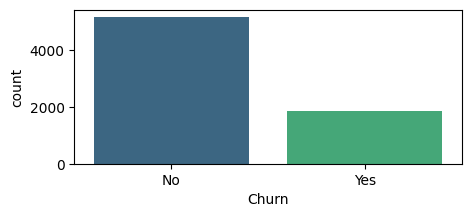

In [ ]:
plt.figure(figsize=(5,2))
sns.countplot(data,x='Churn',hue='Churn', palette='viridis')
plt.show()

**Insights**

1. **Customer retension** : A large proportion of customers continued to stay with service, indicates that customers are happy with service.
2. **Customer Churn** : A significant amount of people churn the service , indicates need to work on improving the service.
3. **Opportunity for Improvment** : Reducing churn rate will lead to customer loyalty and increase revenue streams.
4. **Actionable Insight** : The company should understand the reason for customer churn and should be addresses to avoid the same in future.


**what is the total percentage of customer churn**

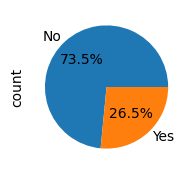

In [ ]:
plt.figure(figsize=(5,2))
data.loc[:,'Churn'].value_counts().plot.pie(autopct='%1.1f%%')
plt.show()

**Insights**
1. **Customer retension** :Approximately 73.5% of the customers stayed to continue the service indicates they trust the service.
2. **Customer Churn** : About 26.5% customers leaving a service indicates indicates people might have issue with service.
3. **Opportunity for Improvment** : Even a single churn reduction would lead to better revennue.
4. **Actionable Insight** : Work on improving the service and reducing churn by optimising price strategies with contract type or with price

**what is the proportion of customers subscribed to each internet service type**

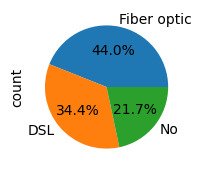

In [ ]:
plt.figure(figsize=(5,2))
data.loc[:,'InternetService'].value_counts().plot.pie(autopct='%1.1f%%')
plt.show()

**Insights**
1. Almost 44% of the customers prefer using Fibre optic which indicates there is a huge demand for this service.
2. 34.4% customers prefer using DSL.
3. Almost 21.7% are not using Internet service at all.
4. High demand for Fibre optic would help us in understanding reason for customer churn.

**What percentage of custonmers are different payment methoids**

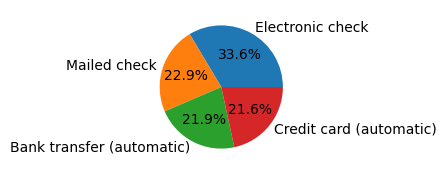

In [ ]:
plt.figure(figsize=(5,2))
data.loc[:,'PaymentMethod'].value_counts().plot.pie(autopct='%1.1f%%')
plt.ylabel(" ")
plt.show()

**Insighs**
* 33.6% of customers prefer using Electronic check
* Almost 22.9% and 21.6% of the customers prefer using Mailed check or credit card
* About 21.9% of customers prefer using bank transfer.
* Maximum customers are prefering Electronic check as their payment method according to preferences.
* It important to analyse payment method with churn to understand with which payment customers are more likely to churn.

**what is the percentage of male and female custometrs**

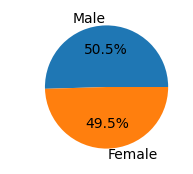

In [ ]:
plt.figure(figsize=(5,2))
data.loc[:,'gender'].value_counts().plot.pie(autopct='%1.1f%%')
plt.ylabel(" ")
plt.show()

**Insights**
1. Almost we have equal proportion of male and femnale customers.

**What percentage of customer fall under different customer Contract type**

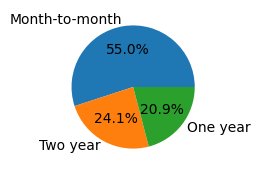

In [ ]:
plt.figure(figsize=(5,2))
data.loc[:,'Contract'].value_counts().plot.pie(autopct='%1.1f%%')
plt.ylabel(" ")
plt.show()

**Insights**
1. Approximately 55% of the customers prefer month-to-month service.
2. Almost 24.1% people prefer Two year and 20.9% of the people prefer one year service.
3. Since maximum customers have opted for month-to-month service , there might be high chance of churn indicates lower customer commitments.
4. Company should encourage month-to-month service customers to long time by offering certain offers or discounts so we can reduce the churn.

**How many customer churn among male and female**

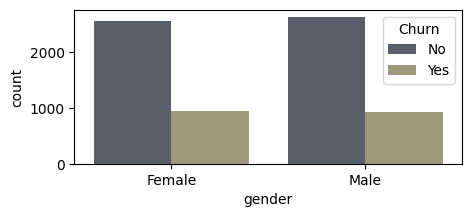

In [ ]:
plt.figure(figsize=(5,2))
sns.countplot(data,x='gender',hue='Churn', palette='cividis')
plt.show()

**Insights**
* There is no major difference in count of churn with male or female.
* Gender might not the strong reason for churn.

**How many customers using internet service will churn**

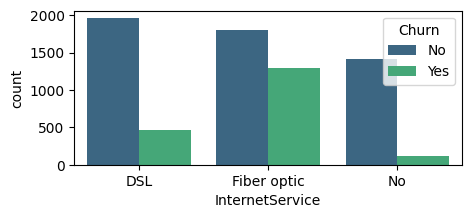

In [ ]:
plt.figure(figsize=(5,2))
sns.countplot(data,x='InternetService',hue='Churn', palette='viridis')
plt.show()

**Insights**
1. Customer churn is very high with customers using Fibre optic service followed by DSL.
2. Customer churn is very low with customers with no Internet Service.
3. Despite Fibre optic being the most preferred Intrernet service among customers resulting in high churn, hence need to work on service quality, prices and tech support to reduce churn.

**How many customers with techsupport would like to churn**

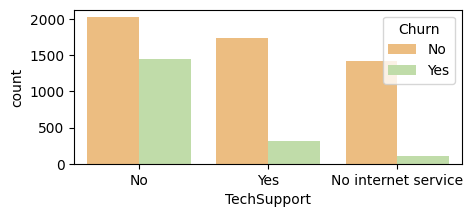

In [ ]:
plt.figure(figsize=(5,2))
sns.countplot(data,x='TechSupport',hue='Churn', palette='Spectral')
plt.show()

**Insights**
1. Customers without Technical Support are more more like to churn compared to people with tech support.
2. Lack of tch support associated with high churn company need to provide proper support need to work providing correct resolutions so that churn can be reduced.

**How many customers are would like to churn with different contract type**

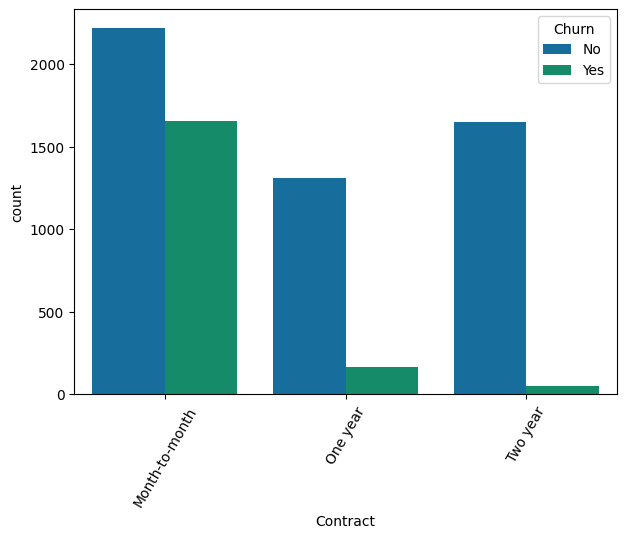

In [ ]:
plt.figure(figsize=(7,5))
sns.countplot(data,x='Contract',hue='Churn', palette='colorblind6')
plt.xticks(rotation=60)
plt.show()

**Insights**
1. Customers who opted for month-to-month service are more likely to churn compared to one year contract or Two year contract.
2. Customers with short term commitments are more like ly to leave compared to long term customers.
3. Company should encourage companies to switch for long term with better offers , discounts or with attractive package.

**How many customer are likely to churn with different payment methods**

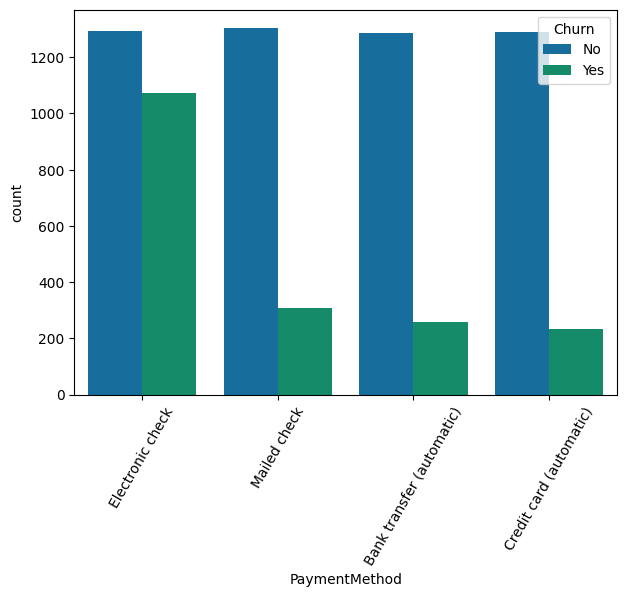

In [ ]:
plt.figure(figsize=(7,5))
sns.countplot(data,x='PaymentMethod',hue='Churn', palette='colorblind6')
plt.xticks(rotation=60)
plt.show()

**Insights**
1. Customers using Electronic check are more likely to churn compared to automatic payments like Bank transfer or credit card.
2. Customers using manual payment are more likely to churn.
3. Encourage customers to switch to automatic payment to retain customers and to reduce churn.

**Customers with dependencies are more likely to churmn**

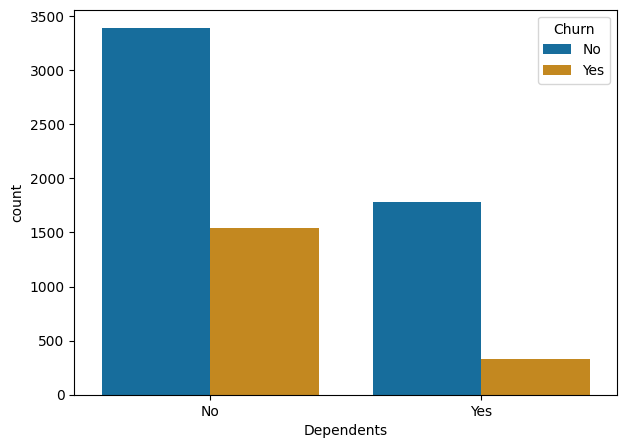

In [ ]:
plt.figure(figsize=(7,5))
sns.countplot(data,x='Dependents',hue='Churn', palette='colorblind')
plt.show()

**Insights**
* Customers with no dependents are more like ly to churn compared to customer with dependents.

**will senior citizen are more likely to churn**

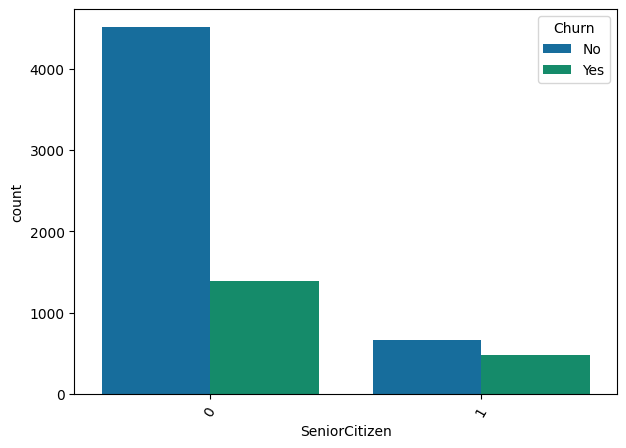

In [ ]:
plt.figure(figsize=(7,5))
sns.countplot(data,x='SeniorCitizen',hue='Churn', palette='colorblind6')
plt.show()

**Insights**
* Customer churn is very high with senior citizen compared to young customers
* Work on providing better service ,offers for senior citizen to avoid churn.

**Are Customer without streaming TV are likely to churn**

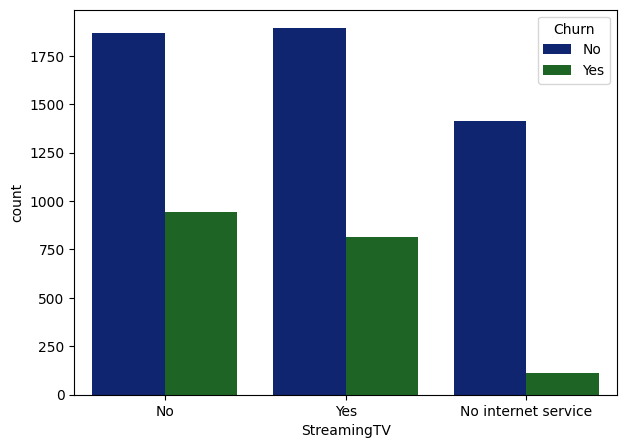

In [ ]:
plt.figure(figsize=(7,5))
sns.countplot(data,x='StreamingTV',hue='Churn', palette='dark6')
plt.show()

**Insights**
1. Customer without streaming TV service are more likely to churn compared to customers with TV services.
2. Offer streaming services to the customers to avoid churn.

**Are Customer without straming Movies are more likely to churn**

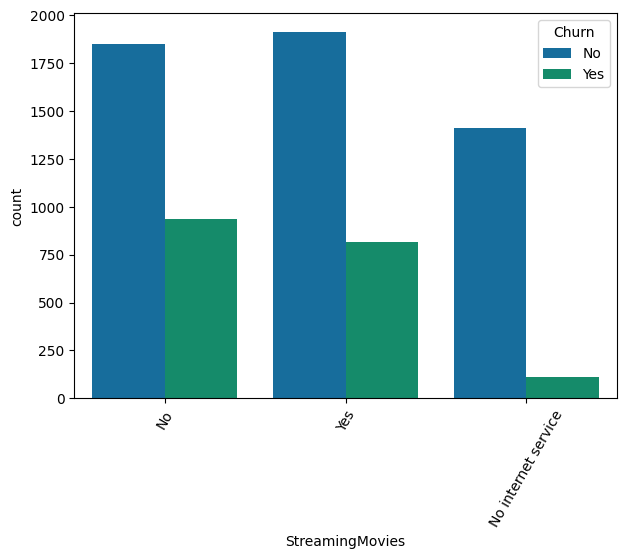

In [ ]:
plt.figure(figsize=(7,5))
sns.countplot(data,x='StreamingMovies',hue='Churn', palette='colorblind6')
plt.xticks(rotation=60)
plt.show()

**Insights**
1. Customer without streaming Movie service are more likely to churn compared to customers with movie services.
2. Offer streaming services to the customers to avoid churn.

**What is the distribution of Monthly Charges**

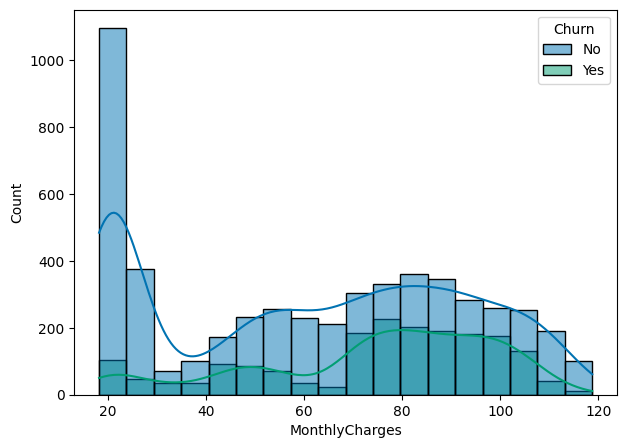

In [ ]:
plt.figure(figsize=(7,5))
sns.histplot(data,x='MonthlyCharges',hue='Churn', palette='colorblind6', kde=True)
plt.show()

**Insights**
* Maximum customers price range vary between 70 to 100.
* There are few customers with very less range or with high range.
* Distribution is normal

#**What is the distribution of Total_Charges**

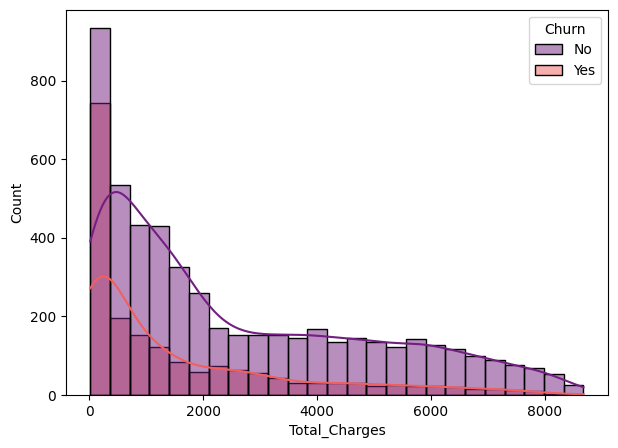

In [ ]:
plt.figure(figsize=(7,5))
sns.histplot(data,x='Total_Charges',hue='Churn', palette='magma', kde=True)
plt.show()

**Insights**

* more number of people are pay charges inbetween 1000 to 300
* the people who pay more charges are not like to churn
* less number of people are pay high charges ranges beween 6000 to 8000
* few members are like to churn who pay more monthly charges


**whata is the Distribution of Tenure**

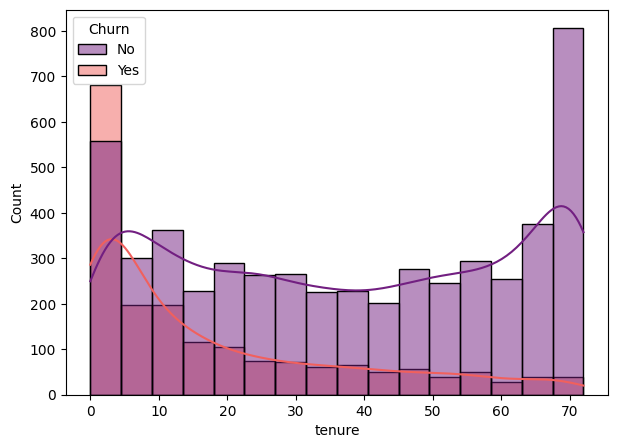

In [ ]:
plt.figure(figsize=(7,5))
sns.histplot(data,x='tenure',hue='Churn', palette='magma', kde=True)
plt.show()

**Insights**

* less number of people are tenure they have intrested to churn the service
* more number of peoples are not ready to churn the service
* the distribution of tenure is **normal**

**Are there any extreme values in Monthly Charges**

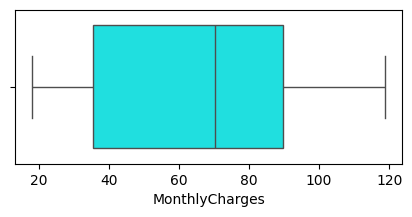

In [ ]:
plt.figure(figsize=(5,2))
sns.boxplot(data,x='MonthlyCharges',color='cyan')
plt.show()

#**Insights**

* there is no outliers in the Monthly charges

**are there any extreame values in Totral Charges**

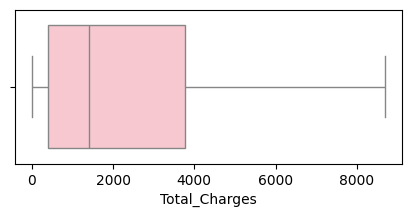

In [ ]:
plt.figure(figsize=(5,2))
sns.boxplot(data,x='Total_Charges',color='pink')
plt.show()

#**Insights**

* there is no outliers in the Total Charges

**Are there any extreame values in Tenure**

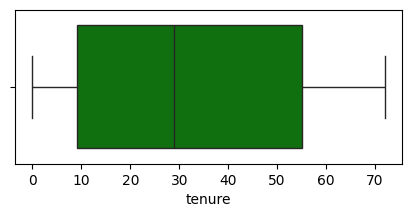

In [ ]:
plt.figure(figsize=(5,2))
sns.boxplot(data,x='tenure',color='green')
plt.show()

#**Insights**

* There is no outliers in the tenure

**Will average monthly charges impact a churn**

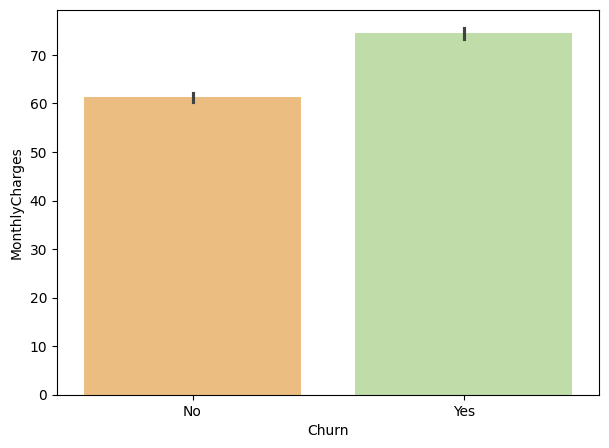

In [ ]:
plt.figure(figsize=(7,5))
sns.barplot(data,x='Churn',y='MonthlyCharges', hue='Churn',palette='Spectral')
plt.show()

**Insights**
* Chance of churn is high in customers who pay highest month charges.
* Reducing price or providing offers might reduce churn

**Will tenure impact a churn**

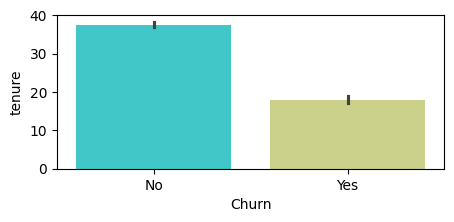

In [ ]:
plt.figure(figsize=(5,2))
sns.barplot(data,x='Churn',y='tenure',hue='Churn', palette='rainbow')
plt.show()

#**Insights**

* there are more peoples are  would not like to tenure
* only less amount of people are tenure means
* they would like to churn the service

**How monthly charges with different contract type will effect to churn**

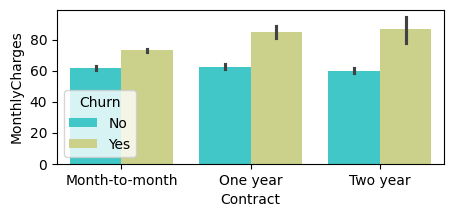

In [ ]:
plt.figure(figsize=(5,2))
sns.barplot(data,x='Contract',y='MonthlyCharges',hue='Churn', palette='rainbow')
plt.show()

**Insights**
1. Customers with month-to-month service and with high monthly charges are more likely to churn.
2. Customers with one year contract or  two year with high monthly charges are more likely churn.
3. Revise the pricing stragies to reduce churn.

**How Tech support and total charges impact on churn**

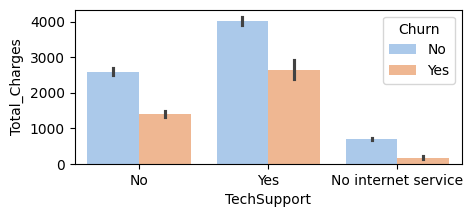

In [ ]:
plt.figure(figsize=(5,2))
sns.barplot(data,x='TechSupport',y='Total_Charges',hue='Churn', palette='pastel')
plt.show()

**Insights**
1. Customers with good tech support and high total charges are less likely to churn.
2. Customers with lower charges and no tech support are more likely to churn.

**How internet service and TechSupport combined impact churn**




In [ ]:
df = pd.crosstab([data['InternetService'],data['TechSupport']],data['Churn'])

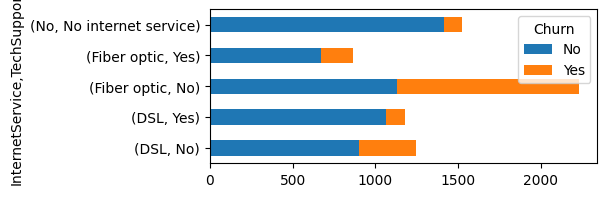

In [ ]:
df.plot(kind='barh', stacked=True,figsize=(5,2))
plt.show()

**Insights**
1. Customers using Fibre optic and not getting enough tech support are more likely to churn.
2. Customers with DSL with no tech support are more likely to churn
3. Customers with tech support are less likely to churn.
4. Ensure customers queries are addressed so we can reduce the customer churn

**How Techsupport ,contract impact Churn**

In [ ]:
df=pd.crosstab([data['TechSupport'],data['Contract']],data['Churn'])

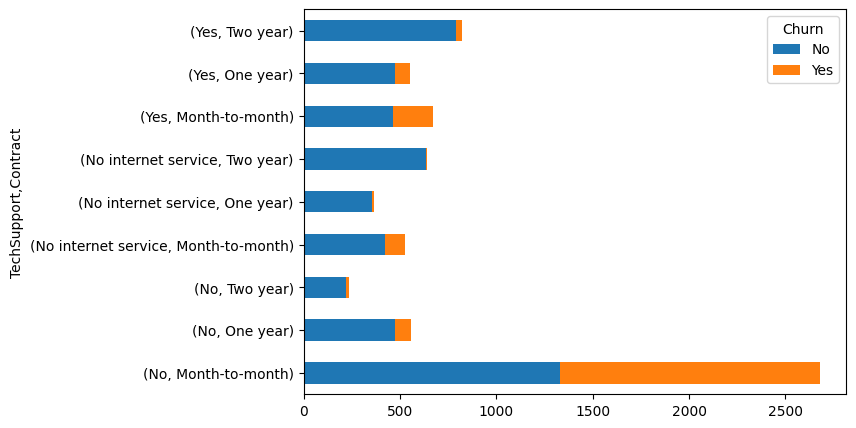

In [ ]:
df.plot(kind='barh',stacked=True,figsize=(7,5))
plt.show()

**Insights**
* Customer with month to month service and not getting tech support are more likely to churn.

**Is there any correlationship between numerical data**

<Axes: >

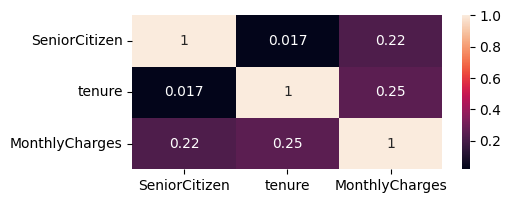

In [ ]:
plt.figure(figsize=(5,2))
sns.heatmap(num_data.corr(),annot=True)
plt.show()

**Is there any pairwise relationship between numerical columns**

<Figure size 500x200 with 0 Axes>

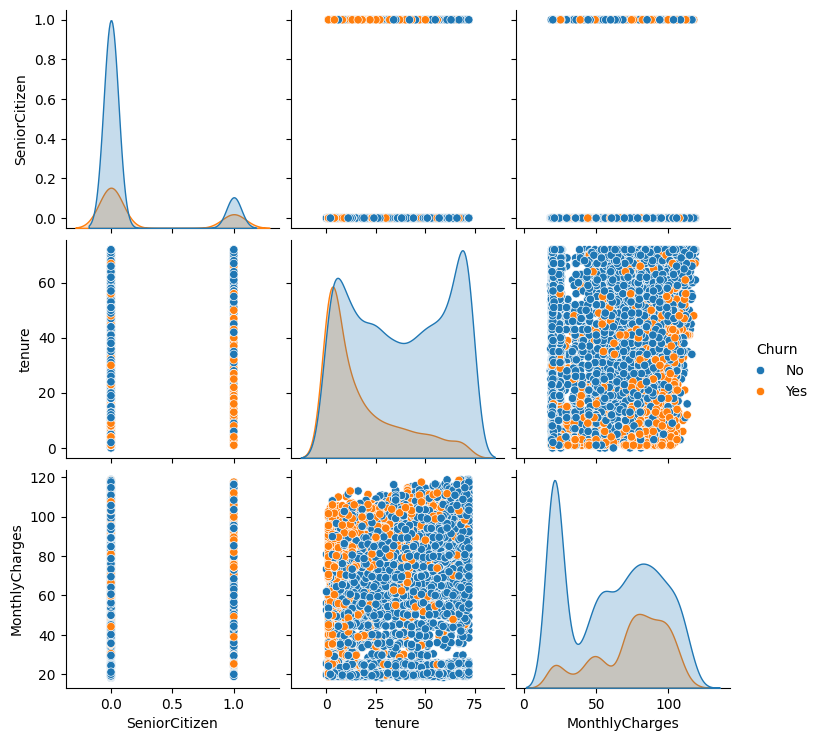

In [ ]:
plt.figure(figsize=(5,2))
sns.pairplot(data,hue='Churn')
plt.show()

**Is there any correlation between tenure and monthly charges**

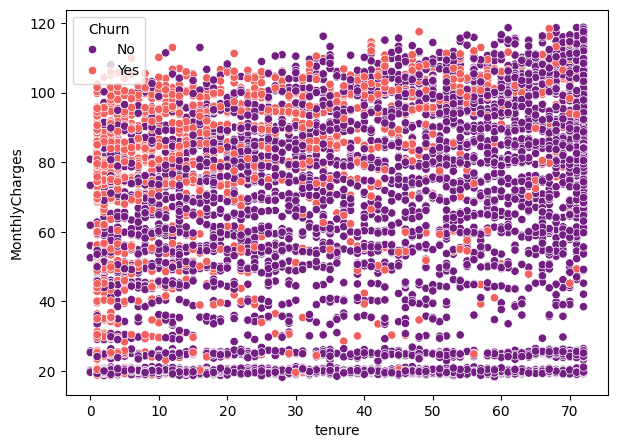

In [ ]:
plt.figure(figsize=(7,5))
sns.scatterplot(data,x='tenure',y='MonthlyCharges', hue='Churn',palette='magma')
plt.show()

**Insights**

* people who have high monthly charges they would like to tennure
* less amount of people are tenure with high monthly charges
* people with high monthly charges are not going to churn

#**Overall Conclusion**

- **Churn rate** is around 26%, which is moderate but concerning.

- **Month-to-month contracts** show the highest churn.

- Customers paying **higher monthly charges** are more likely to leave.

- **Fiber optic** users have higher churn despite contributing higher revenue.

- Customers without **tech support** churn more.

- **Automatic payment** users churn less.

- Demographics like gender have minimal impact.

- Customers with long-term contracts and added services stay longer and generate higher total revenue.

👉 Churn is mainly driven by price sensitivity, short-term contracts, and lack of value-added services, not demographics.

#**Key Recommendation**

1️⃣ **Promote Long-Term Contracts**

Offer discounts, loyalty rewards, or bundled benefits to move customers from month-to-month to annual plans.

2️⃣ Improve Value for **High-Paying Customers**

Enhance service quality, speed, and support for fiber and high-charge customers to reduce dissatisfaction.

3️⃣ Encourage **Automatic Payments**

Provide incentives for switching to auto-pay methods to improve retention.

4️⃣ Bundle **Tech Support**

Promote tech support packages to increase engagement and reduce churn risk.

5️⃣ Focus on **Early Retention**

Improve onboarding experience and engagement in the first few months to prevent early churn.

In [ ]:
data

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,NaN,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes
